In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading athe data set and encoding it

In [ ]:
df = pd.read_csv("/content/OnlineRetail.csv", encoding="latin1")

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
276170,561034,21967,PACK OF 12 SKULL TISSUES,4.0,7/24/2011 11:45,0.29,15506.0,United Kingdom
276171,561034,21982,PACK OF 12 SUKI TISSUES,1.0,7/24/2011 11:45,0.29,15506.0,United Kingdom
276172,561034,22615,PACK OF 12 CIRCUS PARADE TISSUES,2.0,7/24/2011 11:45,0.29,15506.0,United Kingdom
276173,561034,22616,PACK OF 12 LONDON TISSUES,4.0,7/24/2011 11:45,0.29,15506.0,United Kingdom


In [ ]:
df.shape

(276175, 8)

looking for the  missing value

In [ ]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276175 entries, 0 to 276174
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    276175 non-null  object 
 1   StockCode    276175 non-null  object 
 2   Description  275168 non-null  object 
 3   Quantity     276174 non-null  float64
 4   InvoiceDate  276174 non-null  object 
 5   UnitPrice    276174 non-null  float64
 6   CustomerID   197298 non-null  float64
 7   Country      276174 non-null  object 
dtypes: float64(3), object(5)
memory usage: 16.9+ MB


np.int64(2223)

data is containing missing values

In [ ]:
# Remove missing CustomerID
df = df[df['CustomerID'].notnull()]

# Remove negative quantities
df = df[df['Quantity'] > 0]

df.shape


(192484, 8)

# Create TotalPrice column

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


RFM analysis

In [ ]:
import datetime as dt

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Define snapshot date
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

print(snapshot_date)
# Group by customer
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'count',                                    # Frequency
    'TotalPrice': 'sum'                                      # Monetary
})

rfm.rename(columns={'InvoiceDate':'Recency',
                    'InvoiceNo':'Frequency',
                    'TotalPrice':'Monetary'}, inplace=True)

rfm.head()


2011-07-25 11:45:00


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,188,1,77183.60
12347.0,45,102,2205.95
12348.0,111,28,1487.24
12350.0,172,17,334.40
12352.0,124,38,1561.81


In [ ]:
# Ensure AOV exists
if 'AOV' not in rfm.columns:
    rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

# Features and Target
X = rfm[['Recency','Frequency','Monetary','AOV']]
y = rfm['CLTV']


CLTV Prediction

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
# Ensure AOV exists
if 'AOV' not in rfm.columns:
    rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

# Ensure CLTV exists
if 'CLTV' not in rfm.columns:
    # Simple formula CLTV = AOV * Purchase Frequency * Gross Margin
    purchase_frequency = rfm['Frequency'].sum() / rfm.shape[0]
    gross_margin = 1  # if no cost data
    rfm['CLTV'] = (rfm['AOV'] * purchase_frequency) * gross_margin

# Now you can safely run regression
X = rfm[['Recency','Frequency','Monetary','AOV']]
y = rfm['CLTV']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ---------------- Random Forest Regressor ----------------
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
rf_preds = rf_reg.predict(X_test)

rf_rmse = sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Regressor Results:")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R²:", rf_r2)

# ---------------- XGBoost Regressor ----------------
xgb_reg = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
xgb_reg.fit(X_train, y_train)
xgb_preds = xgb_reg.predict(X_test)

xgb_rmse = sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)

print("\nXGBoost Regressor Results:")
print("RMSE:", xgb_rmse)
print("MAE:", xgb_mae)
print("R²:", xgb_r2)


Random Forest Regressor Results:
RMSE: 152551.41076546325
MAE: 5644.996676532041
R²: 0.08915415139084748

XGBoost Regressor Results:
RMSE: 151944.5973647098
MAE: 5960.398281375626
R²: 0.09638599778965784


In [ ]:
!pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 15.3 MB/s eta 0:00:00


In [ ]:

from lifetimes import BetaGeoFitter, GammaGammaFitter

# Prepare data
from lifetimes.utils import summary_data_from_transaction_data

summary = summary_data_from_transaction_data(df, 'CustomerID', 'InvoiceDate', monetary_value_col='TotalPrice', observation_period_end=snapshot_date)


# Add a small penalizer to improve convergence
bgf = BetaGeoFitter(penalizer_coef=0.1)   # try 0.1, 0.5, or 1.0 if needed
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

# Predict transactions for 6 months
summary['pred_purchases'] = bgf.predict(180, summary['frequency'], summary['recency'], summary['T'])

# Keep only customers with positive monetary value
summary = summary[summary['monetary_value'] > 0]

ggf = GammaGammaFitter(penalizer_coef=0.1)   # add penalizer to stabilize
ggf.fit(summary['frequency'], summary['monetary_value'])

# Predict CLTV for 6 months
summary['CLTV'] = ggf.customer_lifetime_value(
    bgf, summary['frequency'], summary['recency'], summary['T'], summary['monetary_value'], time=6, freq='D', discount_rate=0.01)

summary.head()


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,frequency,recency,T,monetary_value,pred_purchases,CLTV
CustomerID,,,,,,
12347.0,3.0,184.0,230.0,498.053333,2.296180,1498.208702
12348.0,2.0,110.0,221.0,297.220000,1.699808,805.673144
12352.0,3.0,34.0,159.0,421.770000,3.090773,1707.977600
12356.0,1.0,80.0,188.0,481.460000,1.170684,2557.414150
12359.0,2.0,142.0,194.0,1474.115000,1.890899,4439.551932


In [ ]:
# Segment customers into 4 groups
summary['Segment'] = pd.qcut(summary['CLTV'], 4, labels=['Low','Medium','High','Very High'])
summary['Segment'].value_counts()


,count
Segment,
Low,424
Medium,424
Very High,424
High,423


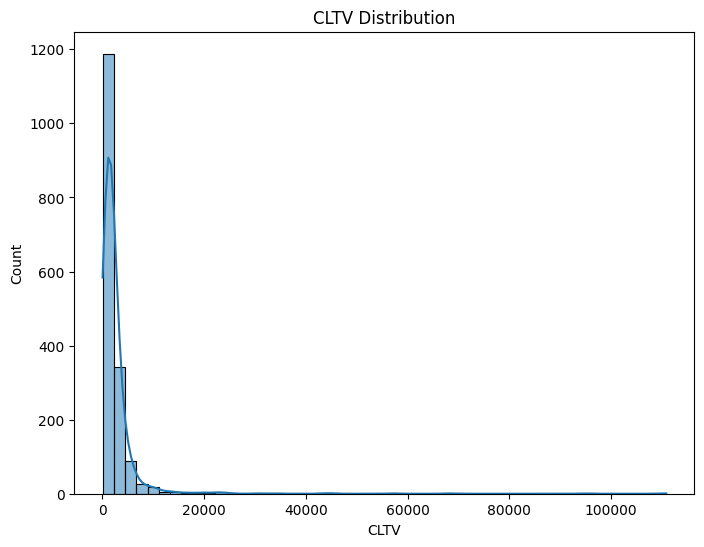

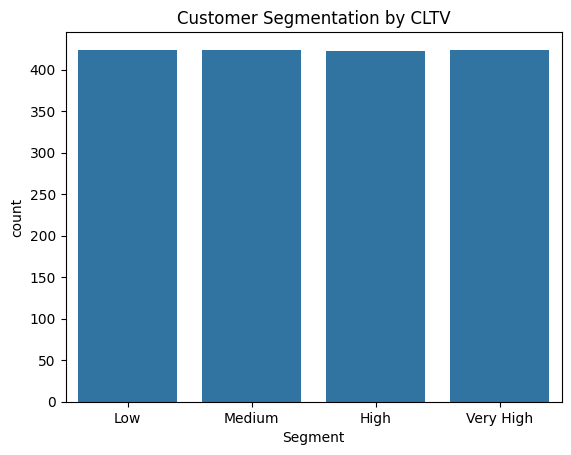

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.histplot(summary['CLTV'], bins=50, kde=True)
plt.title("CLTV Distribution")
plt.show()

sns.countplot(x='Segment', data=summary, order=['Low','Medium','High','Very High'])
plt.title("Customer Segmentation by CLTV")
plt.show()


In [ ]:
# Quartile-based scoring (1=lowest, 4=highest)
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method="first"), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

# Combine into one RFM_Score
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()


,Recency,Frequency,Monetary,AOV,CLTV,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,,,
12346.0,188,1,77183.60,77183.600000,4.801748e+06,1,1,4,114
12347.0,45,102,2205.95,21.626961,1.345457e+03,3,4,4,344
12348.0,111,28,1487.24,53.115714,3.304436e+03,2,2,4,224
12350.0,172,17,334.40,19.670588,1.223747e+03,1,2,2,122
12352.0,124,38,1561.81,41.100263,2.556931e+03,1,3,4,134


In [ ]:
# Define simple segmentation map
def segment(x):
    if x.startswith("44"):
        return "Champions"
    elif x.startswith("34") or x.startswith("43"):
        return "Loyal"
    elif x.startswith("14") or x.startswith("24"):
        return "Potential Loyalist"
    elif x.startswith("41") or x.startswith("42"):
        return "Recent Customers"
    elif x.startswith("31") or x.startswith("32"):
        return "At Risk"
    else:
        return "Others"

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

# Segment count
print(rfm['Segment'].value_counts())


Segment
Others                1611
Loyal                  415
Champions              386
At Risk                321
Recent Customers       204
Potential Loyalist     157
Name: count, dtype: int64


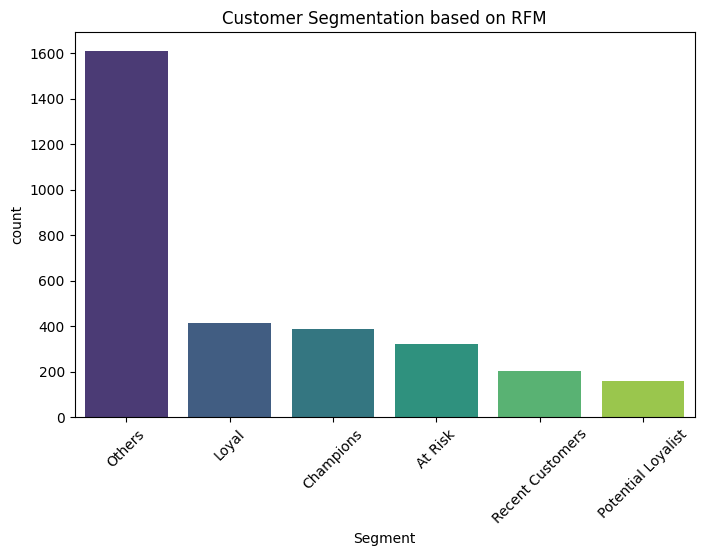

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette="viridis")
plt.xticks(rotation=45)
plt.title("Customer Segmentation based on RFM")
plt.show()


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Assuming you already have RFM + CLTV dataframe
df = rfm.copy()


# Create target variable (1 = High CLTV, 0 = Low CLTV)
threshold = df['CLTV'].quantile(0.70)  # top 30% customers
df['High_CLTV'] = np.where(df['CLTV'] >= threshold, 1, 0)

# Features (R, F, M) → Predict target (High_CLTV)
X = df[['Recency', 'Frequency', 'Monetary']]
y = df['High_CLTV']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize (for XGBoost performance, RF doesn’t need scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, rf_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_preds))


Random Forest Results:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       433
           1       0.97      0.89      0.93       186

    accuracy                           0.96       619
   macro avg       0.96      0.94      0.95       619
weighted avg       0.96      0.96      0.96       619

Confusion Matrix:
 [[427   6]
 [ 20 166]]


In [ ]:
# XGBoost
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

xgb_preds = xgb_model.predict(X_test_scaled)

print("XGBoost Results:")
print(classification_report(y_test, xgb_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_preds))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [06:00:43] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       433
           1       0.99      0.93      0.96       186

    accuracy                           0.98       619
   macro avg       0.98      0.96      0.97       619
weighted avg       0.98      0.98      0.98       619

Confusion Matrix:
 [[432   1]
 [ 13 173]]


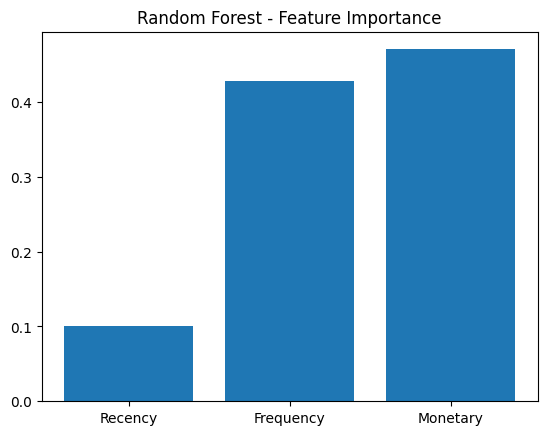

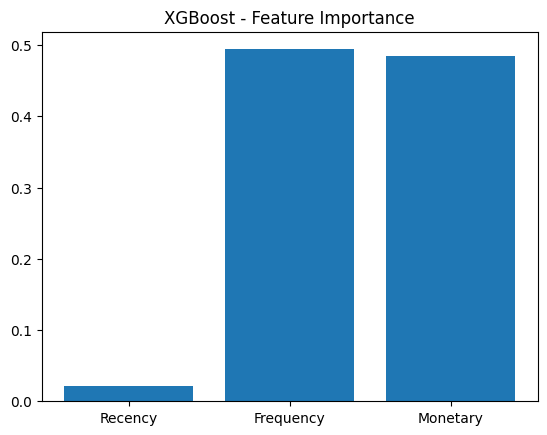

In [ ]:
import matplotlib.pyplot as plt

# Random Forest Feature Importance
importances = rf_model.feature_importances_
features = X.columns

plt.bar(features, importances)
plt.title("Random Forest - Feature Importance")
plt.show()

# XGBoost Feature Importance
xgb_importances = xgb_model.feature_importances_
plt.bar(features, xgb_importances)
plt.title("XGBoost - Feature Importance")
plt.show()


In [ ]:
import numpy as np

# Define a churn threshold (example: Recency > 90 days = churned)
threshold = 90
df['Churn'] = np.where(df['Recency'] > threshold, 1, 0)

# Calculate churn rate
churn_rate = df['Churn'].mean()

print(f"Churn Rate: {churn_rate:.2%}")



In [ ]:
print(df.columns)
print(df)


Index(['Recency', 'Frequency', 'Monetary', 'AOV', 'CLTV', 'R_score', 'F_score',
       'M_score', 'RFM_Score', 'Segment', 'High_CLTV', 'Churn'],
      dtype='object')
            Recency  Frequency  Monetary           AOV          CLTV R_score  \
CustomerID                                                                     
12346.0         188          1  77183.60  77183.600000  4.801748e+06       1   
12347.0          45        102   2205.95     21.626961  1.345457e+03       3   
12348.0         111         28   1487.24     53.115714  3.304436e+03       2   
12350.0         172         17    334.40     19.670588  1.223747e+03       1   
12352.0         124         38   1561.81     41.100263  2.556931e+03       1   
...             ...        ...       ...           ...           ...     ...   
18273.0         120          1     51.00     51.000000  3.172813e+03       2   
18280.0         140         10    180.60     18.060000  1.123549e+03       1   
18281.0          43          7   

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Example: X_train, X_test, y_train, y_test are already defined

# 1️⃣ Train Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]  # probability of positive class

# 2️⃣ Train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 3️⃣ Calculate AUC
auc_rf = roc_auc_score(y_test, y_pred_prob_rf)
auc_xgb = roc_auc_score(y_test, y_pred_prob_xgb)

# 4️⃣ Print results
print("Random Forest AUC:", auc_rf)
print("XGBoost AUC:", auc_xgb)


Random Forest AUC: 0.995946013062157
XGBoost AUC: 0.9980940673967569


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [06:03:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
